# EDM UNet Train-Size Sweep — Sampler σ-Range Fix and Attribution Ablation

Follow-up to `edm_unet_train_size_sweep.ipynb`, which found that the EDM UNet shows
essentially **no memorization at any n_train ∈ [4, 32]** (coarse ratio 0.81–0.91, fine ≈ 1.0),
flat across checkpoints, even though the training loss keeps falling — while the GMM ceiling
sits at 0.03–0.22 under the *same* sampler.

**Diagnosis (most likely cause): train/sample σ-range mismatch.**
- Training draws σ ~ LogNormal(P_mean=−1.2, P_std=1.2): median σ ≈ 0.30, P(σ > 10) ≈ 0.2%,
  P(σ > 40) ≈ 0. The conditioning input c_noise = ln(σ)/4 at σ = 80 is far outside anything
  the network saw.
- Sampling starts at σ_max = 80 (the Karras ImageNet-scale default). For t ∈ (0.80, 1] the
  reverse SDE runs on an *extrapolated* score. EDM preconditioning makes this failure silent:
  c_skip → 0 at large σ, so the score degrades to ≈ −x/σ² — generic contraction carrying no
  information about which training-point basin to enter. But the basin (mode) decision is
  made exactly at large σ; that is where the GMM — whose score is exact at all σ — wins.
- Supporting evidence: the VP UNet in `memorization_regime_sweep.ipynb` (same architecture)
  did memorize (coarse ≈ 0.3–0.8); VP training samples t uniformly over the entire schedule
  used at sampling, so it has no such gap.

**Secondary suspect: SDE discretization.** The regime sweep measured that cutting
1000 → 500 Euler–Maruyama steps inflated the VP UNet coarse ratio from ~0.3 to ~0.79.

**Fix + attribution.** Training is unchanged (identical seeds → identical networks; the σ
distribution the net trains on is not the issue — the sampler's range is). We re-evaluate
under a small grid so the cause is attributed, not assumed:

| config | σ_max | SDE steps | tests |
|---|---|---|---|
| A | 80 | 500  | anchor — reproduces the negative result |
| B | 80 | 2000 | discretization only |
| C | 10 | 500  | σ-range match only |
| D | 10 | 1000 | both (the proposed fix) |

σ_max = 10 covers ~99.8% of the training σ distribution and is still 10× the data std, so
mixing at initialization is preserved. All n_train values are evaluated under A and D; the
extremes n_train ∈ {4, 32} get the full A/B/C/D grid. The GMM reference is recomputed under
every config so ceilings stay comparable.

**Expected outcome:** if C ≈ D ≪ A ≈ B, the σ-range mismatch is the cause; if B ≪ A,
discretization dominates; if all ≈ A, the cause is deeper (architecture/objective) and the
next step is a Karras/Heun deterministic sampler or broader training σ coverage.

**Runtime (CPU):** 4 trainings × 5000 full-batch steps (~1–2 h, same as the previous
notebook) + ~11k UNet SDE steps and ~11k GMM SDE steps of sampling (~1.5–2 h).
Trained networks are saved to `results/data/edm_unet_ntrain_checkpoints.pt` this time,
so future re-evaluations need no retraining.

In [1]:
import sys, os, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import diffusion_score_models as score_models
from multiband_data_utils import (
    generate_multiband_dataset_postmask,
    make_radial_band_mask,
    radial_bandpass,
    make_radial_k_grid,
)
from edm import EDMPrecond, EDMScoreWrapper, train_edm

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


In [2]:
# ── Data generation (same pool as edm_unet_train_size_sweep) ──
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=42, normalize=True,
)
bands = result.get('bands', {c['name']: c['band'] for c in components})
N = 128
x_all = result['combined'].to(device)   # (200, 128, 128) — sliced per n_train below

print(f'Data pool: {x_all.shape}')
print(f'Bands: {bands}')

Data pool: torch.Size([200, 128, 128])
Bands: {'coarse': (0.5, 4.0), 'mid1': (4.0, 10.0), 'mid2': (10.0, 18.0), 'fine': (18.0, 32.0)}


In [3]:
# ── SmallUNet architecture (identical to edm_tikhonov_memorization) ──

class SinusoidalEmbedding(nn.Module):
    """Standard sinusoidal time embedding, maps scalar t -> vector of size dim."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / (half - 1)
        )
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    """Conv residual block with additive time embedding."""
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        def ngroups(ch):
            for g in [8, 4, 2, 1]:
                if ch % g == 0: return g
        self.norm1    = nn.GroupNorm(ngroups(in_ch),  in_ch)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(ngroups(out_ch), out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SmallUNet(nn.Module):
    """
    2-level U-Net: 128->64->32 (spatial), then back up.
    Predicts a denoised image given noisy input and conditioning scalar.
    """
    def __init__(self, base_channels=16, emb_dim=64):
        super().__init__()
        C, E = base_channels, emb_dim
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(E), nn.Linear(E, E*2), nn.SiLU(), nn.Linear(E*2, E)
        )
        self.conv_in = nn.Conv2d(1,   C,   3, padding=1)
        self.enc1    = ResBlock(C,   C,   E)
        self.down1   = nn.Conv2d(C,  C*2, 3, stride=2, padding=1)   # 128->64
        self.enc2    = ResBlock(C*2, C*2, E)
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1)  # 64->32
        self.mid     = ResBlock(C*4, C*4, E)
        self.up2     = nn.ConvTranspose2d(C*4, C*2, 2, stride=2)    # 32->64
        self.dec2    = ResBlock(C*4, C*2, E)   # skip concat
        self.up1     = nn.ConvTranspose2d(C*2, C,   2, stride=2)    # 64->128
        self.dec1    = ResBlock(C*2, C,   E)   # skip concat
        self.conv_out = nn.Conv2d(C, 1, 3, padding=1)
    def forward(self, x, t):
        emb = self.time_embed(t)
        h   = self.conv_in(x)
        h1  = self.enc1(h,  emb)
        h2  = self.enc2(self.down1(h1), emb)
        hm  = self.mid( self.down2(h2), emb)
        hu  = self.dec2(torch.cat([self.up2(hm), h2], dim=1), emb)
        hu  = self.dec1(torch.cat([self.up1(hu), h1], dim=1), emb)
        return self.conv_out(hu)


print(f'SmallUNet params: {sum(p.numel() for p in SmallUNet().parameters()):,}')

SmallUNet params: 195,697


In [4]:
# ── Analysis helpers (same as edm_tikhonov_memorization / analyze_coarse_fine_memorization.py) ──

@torch.no_grad()
def band_component(x, band, norm='forward'):
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse(x_gen, x_train, coarse_band):
    cg = band_component(x_gen, coarse_band).flatten(1)
    ct = band_component(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks(N, k_edges, device):
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)


@torch.no_grad()
def ring_rel_l2(xa, xb, ring_masks, fft_norm=None, eps=1e-12):
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb
    rm = ring_masks.unsqueeze(0).to(Xa.device)
    num = (D.abs() ** 2).unsqueeze(1) * rm
    den = (Xa.abs() ** 2).unsqueeze(1) * rm
    num = num.sum(dim=(-2, -1))
    den = den.sum(dim=(-2, -1)).clamp_min(eps)
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors(xg, xtr, ring_masks, n_ref=64, fft_norm=None):
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)  # (n_ref, G, K)


def ring_idx_for_band(band, k_centers):
    lo, hi = band
    return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)


# Precompute wavenumber grid and ring masks
kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + 1.5, 1.0, device=device)
ring_masks = make_ring_masks(N, k_edges, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])
coarse_r = ring_idx_for_band(bands['coarse'], k_centers)
fine_r   = ring_idx_for_band(bands['fine'],   k_centers)
print(f'Ring masks: {ring_masks.shape}, k range: [{k_centers[0]:.1f}, {k_centers[-1]:.1f}]')

Ring masks: torch.Size([91, 128, 128]), k range: [1.0, 91.0]


In [5]:
# ── Verify the σ-range mismatch numerically ──
P_MEAN, P_STD = -1.2, 1.2
from scipy.stats import norm as sp_norm
for s in [5, 10, 40, 80]:
    p = 1 - sp_norm.cdf((math.log(s) - P_MEAN) / P_STD)
    print(f'P(training sigma > {s:>2d}) = {p:.2e}')

# fraction of the reverse-SDE time axis spent at sigma > 10 when sigma_max = 80
t_sigma10 = math.log(10 / 0.002) / math.log(80 / 0.002)
print(f'\nWith sigma_max=80: sigma > 10 for t in ({t_sigma10:.3f}, 1] '
      f'-> first {100*(1-t_sigma10):.0f}% of SDE steps run on an extrapolated score')

P(training sigma >  5) = 9.61e-03
P(training sigma > 10) = 1.76e-03
P(training sigma > 40) = 2.31e-05
P(training sigma > 80) = 1.65e-06

With sigma_max=80: sigma > 10 for t in (0.804, 1] -> first 20% of SDE steps run on an extrapolated score


In [6]:
# ── Train the UNets (identical to edm_unet_train_size_sweep: same seed -> same nets) ──
# Only the final checkpoint is kept: the previous sweep showed no evolution across
# [1000, 3000, 5000]. State dicts are saved to disk so re-evaluation never needs retraining.

N_TRAIN_SWEEP = [4, 8, 16, 32]
TOTAL_STEPS   = 5000

results_dir = os.path.join(repo_root, 'results', 'data')
os.makedirs(results_dir, exist_ok=True)
ckpt_path = os.path.join(results_dir, 'edm_unet_ntrain_checkpoints.pt')

trained = {}   # n_train -> EDMPrecond (eval mode)

if os.path.exists(ckpt_path):
    print(f'Loading saved checkpoints from {ckpt_path}')
    saved_ckpts = torch.load(ckpt_path, map_location=device, weights_only=False)
    for n_train, entry in saved_ckpts.items():
        unet = SmallUNet(base_channels=16, emb_dim=64).to(device)
        precond = EDMPrecond(unet, sigma_data=entry['sigma_data']).to(device)
        precond.load_state_dict(entry['state_dict'])
        precond.eval()
        trained[n_train] = precond
        print(f'  n_train={n_train}: loaded (sigma_data={entry["sigma_data"]:.4f})')
else:
    saved_ckpts = {}
    for n_train in N_TRAIN_SWEEP:
        print(f'\n===== training n_train = {n_train} =====')
        train_data_flat = x_all[:n_train].reshape(n_train, -1).contiguous()
        ckpts = train_edm(
            train_data_flat, grid_size=N,
            total_steps=TOTAL_STEPS, checkpoint_at=[TOTAL_STEPS],
            base_channels=16, emb_dim=64,
            lr=1e-3, batch_size=n_train,   # full-batch
            P_mean=P_MEAN, P_std=P_STD,
            seed=0, device=device,
            UNetClass=SmallUNet,
        )
        precond = ckpts[TOTAL_STEPS]
        trained[n_train] = precond
        saved_ckpts[n_train] = {
            'state_dict': precond.state_dict(),
            'sigma_data': precond.sigma_data,
            'n_train': n_train, 'total_steps': TOTAL_STEPS, 'seed': 0,
        }
    torch.save(saved_ckpts, ckpt_path)
    print(f'\nCheckpoints saved to {ckpt_path}')


===== training n_train = 4 =====
Estimated sigma_data = 0.9491
  step 1/5000  loss=1.004498
  step 500/5000  loss=0.132439
  step 1000/5000  loss=0.155361
  step 1500/5000  loss=0.082390
  step 2000/5000  loss=0.082719
  step 2500/5000  loss=0.048827
  step 3000/5000  loss=0.044297
  step 3500/5000  loss=0.072672
  step 4000/5000  loss=0.040889
  step 4500/5000  loss=0.048625
  step 5000/5000  loss=0.030999
  >> checkpoint saved at step 5000

===== training n_train = 8 =====
Estimated sigma_data = 0.9810
  step 1/5000  loss=0.913795
  step 500/5000  loss=0.118466
  step 1000/5000  loss=0.108786
  step 1500/5000  loss=0.124451
  step 2000/5000  loss=0.079900
  step 2500/5000  loss=0.075265
  step 3000/5000  loss=0.063926
  step 3500/5000  loss=0.073572
  step 4000/5000  loss=0.041886
  step 4500/5000  loss=0.059511
  step 5000/5000  loss=0.065261
  >> checkpoint saved at step 5000

===== training n_train = 16 =====
Estimated sigma_data = 0.9886
  step 1/5000  loss=0.941432
  step 500/5

In [7]:
# ── Evaluation grid ──
CONFIGS = {
    'A': dict(sigma_max=80.0, n_steps=500),    # anchor: original sampler
    'B': dict(sigma_max=80.0, n_steps=2000),   # discretization only
    'C': dict(sigma_max=10.0, n_steps=500),    # sigma-range match only
    'D': dict(sigma_max=10.0, n_steps=1000),   # both (the fix)
}
MAIN_CONFIGS     = ['A', 'D']    # evaluated for every n_train
ABLATION_NTRAIN  = [4, 32]       # these get the full A/B/C/D grid

N_GEN      = 16
N_RAND_REF = 32


def memorization_metrics(x_gen, xtr):
    idx_nn, _ = nn_by_coarse(x_gen, xtr, bands['coarse'])
    err_nn = ring_rel_l2(x_gen, xtr[idx_nn], ring_masks)
    err_rand = random_baseline_errors(x_gen, xtr, ring_masks, n_ref=N_RAND_REF)
    ratio = (err_nn.unsqueeze(0) / (err_rand + 1e-12)).mean(dim=0)   # (G, K)
    return {
        'ratio': ratio.cpu(),
        'mean_ratio': ratio.mean(dim=0).cpu(),
        'coarse_score': ratio[:, coarse_r].mean(dim=1).cpu(),
        'fine_score': ratio[:, fine_r].mean(dim=1).cpu(),
    }


def eval_config(score_builder, cfg, xtr):
    """score_builder(ve_edm) -> score module for that diffusion; returns metrics dict."""
    ve = score_models.VE_EDM(sigma_min=0.002, sigma_max=cfg['sigma_max'])
    score_fn = score_builder(ve)
    torch.manual_seed(42)
    latents = torch.randn(N_GEN, N*N, device=device)
    samples = ve.SDEsampler(score_fn, latents, num_steps=cfg['n_steps'])
    x_gen = samples.reshape(N_GEN, N, N)
    m = memorization_metrics(x_gen, xtr)
    m['samples'] = x_gen[:4].cpu()
    return m


sweep_results = {}   # n_train -> {'unet': {cfg: metrics}, 'gmm': {cfg: metrics}}

for n_train in N_TRAIN_SWEEP:
    print(f'\n===== n_train = {n_train} =====')
    x_train_img = x_all[:n_train]
    train_data_flat = x_train_img.reshape(n_train, -1).contiguous()
    xtr = x_train_img.detach()
    precond = trained[n_train]

    cfg_names = list(CONFIGS) if n_train in ABLATION_NTRAIN else MAIN_CONFIGS
    unet_res, gmm_res = {}, {}
    for cname in cfg_names:
        cfg = CONFIGS[cname]

        unet_builder = lambda ve: EDMScoreWrapper(precond, ve.marginal_prob_std,
                                                  N, c_tikhonov=0.0).to(device)
        unet_res[cname] = eval_config(unet_builder, cfg, xtr)

        gmm_builder = lambda ve: score_models.GMM_score(train_data_flat, ve.marginal_prob_mean,
                                                        ve.marginal_prob_std).to(device)
        gmm_res[cname] = eval_config(gmm_builder, cfg, xtr)

        print(f"  cfg {cname} (sig_max={cfg['sigma_max']:>4g}, steps={cfg['n_steps']:>4d}): "
              f"UNet coarse={unet_res[cname]['coarse_score'].mean():.4f} "
              f"fine={unet_res[cname]['fine_score'].mean():.4f}  |  "
              f"GMM coarse={gmm_res[cname]['coarse_score'].mean():.4f}")

    sweep_results[n_train] = {'unet': unet_res, 'gmm': gmm_res}

print('\nEvaluation complete.')


===== n_train = 4 =====
  cfg A (sig_max=  80, steps= 500): UNet coarse=0.9112 fine=0.9979  |  GMM coarse=0.2169
  cfg B (sig_max=  80, steps=2000): UNet coarse=0.8954 fine=1.0044  |  GMM coarse=0.2755
  cfg C (sig_max=  10, steps= 500): UNet coarse=0.8773 fine=0.9992  |  GMM coarse=0.2442
  cfg D (sig_max=  10, steps=1000): UNet coarse=0.8959 fine=0.9993  |  GMM coarse=0.2618

===== n_train = 8 =====
  cfg A (sig_max=  80, steps= 500): UNet coarse=0.8787 fine=1.0016  |  GMM coarse=0.1192
  cfg D (sig_max=  10, steps=1000): UNet coarse=0.8587 fine=1.0013  |  GMM coarse=0.1055

===== n_train = 16 =====
  cfg A (sig_max=  80, steps= 500): UNet coarse=0.8144 fine=1.0015  |  GMM coarse=0.0743
  cfg D (sig_max=  10, steps=1000): UNet coarse=0.8081 fine=0.9980  |  GMM coarse=0.0626

===== n_train = 32 =====
  cfg A (sig_max=  80, steps= 500): UNet coarse=0.8081 fine=0.9996  |  GMM coarse=0.0294
  cfg B (sig_max=  80, steps=2000): UNet coarse=0.8322 fine=1.0021  |  GMM coarse=0.0294
  cfg C 

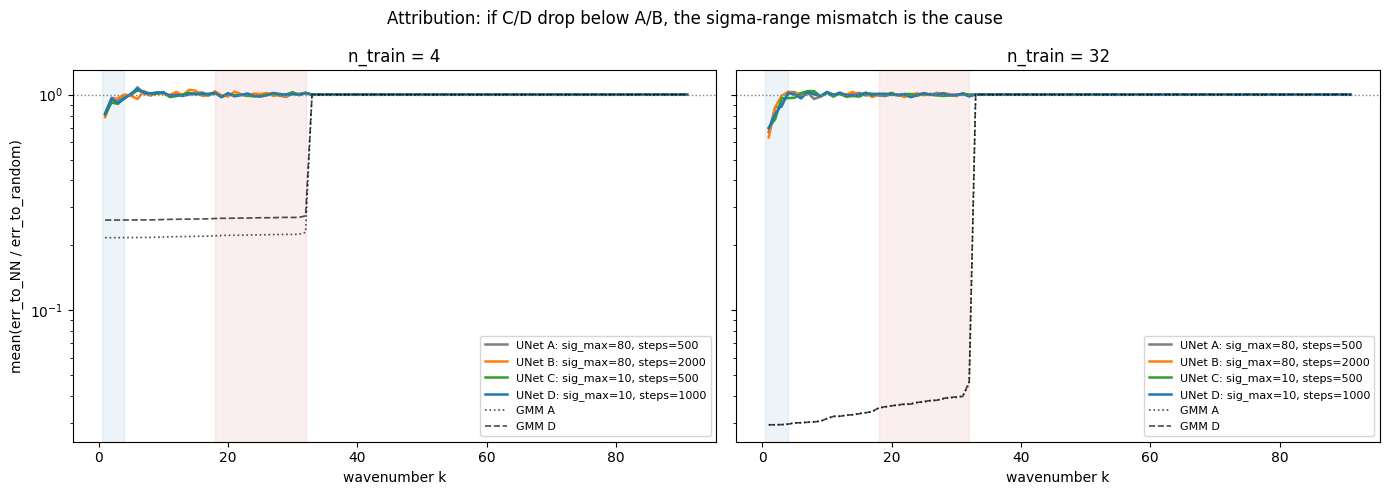

In [8]:
# ── Attribution figure: per-k curves for all configs at the extreme n_train values ──
kc = k_centers.cpu().numpy()
cfg_colors = {'A': 'tab:gray', 'B': 'tab:orange', 'C': 'tab:green', 'D': 'tab:blue'}
cfg_labels = {c: f"{c}: sig_max={CONFIGS[c]['sigma_max']:g}, steps={CONFIGS[c]['n_steps']}"
              for c in CONFIGS}

fig, axes = plt.subplots(1, len(ABLATION_NTRAIN), figsize=(7*len(ABLATION_NTRAIN), 5), sharey=True)
for ax, n_train in zip(np.atleast_1d(axes), ABLATION_NTRAIN):
    for cname in CONFIGS:
        ax.plot(kc, sweep_results[n_train]['unet'][cname]['mean_ratio'].numpy(),
                color=cfg_colors[cname], lw=1.8, label=f'UNet {cfg_labels[cname]}')
    for cname, ls in [('A', ':'), ('D', '--')]:
        ax.plot(kc, sweep_results[n_train]['gmm'][cname]['mean_ratio'].numpy(),
                color='black', lw=1.2, ls=ls, alpha=0.7, label=f'GMM {cname}')
    ax.axhline(1.0, ls=':', color='gray', lw=1)
    for bname, bcolor in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=bcolor, alpha=0.08)
    ax.set_yscale('log')
    ax.set_xlabel('wavenumber k')
    ax.set_title(f'n_train = {n_train}')
    ax.legend(fontsize=8)
np.atleast_1d(axes)[0].set_ylabel('mean(err_to_NN / err_to_random)')
fig.suptitle('Attribution: if C/D drop below A/B, the sigma-range mismatch is the cause', fontsize=12)
plt.tight_layout()
plt.show()

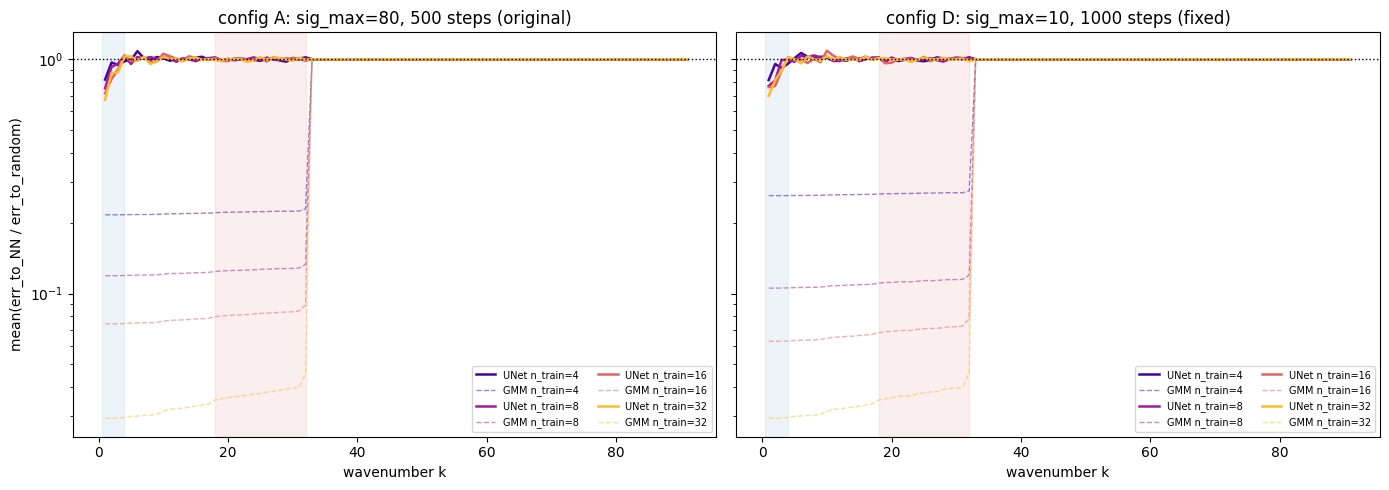

In [9]:
# ── Main figure: mean_ratio(k) per n_train under the fixed sampler (config D) ──
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(N_TRAIN_SWEEP)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, cname, title in zip(axes, ['A', 'D'],
                            ['config A: sig_max=80, 500 steps (original)',
                             'config D: sig_max=10, 1000 steps (fixed)']):
    for color, n_train in zip(colors, N_TRAIN_SWEEP):
        ax.plot(kc, sweep_results[n_train]['unet'][cname]['mean_ratio'].numpy(),
                color=color, lw=1.8, label=f'UNet n_train={n_train}')
        ax.plot(kc, sweep_results[n_train]['gmm'][cname]['mean_ratio'].numpy(),
                color=color, lw=1.0, ls='--', alpha=0.5, label=f'GMM n_train={n_train}')
    ax.axhline(1.0, ls=':', color='black', lw=1)
    for bname, bcolor in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=bcolor, alpha=0.08)
    ax.set_yscale('log')
    ax.set_xlabel('wavenumber k')
    ax.set_title(title)
    ax.legend(fontsize=7, ncol=2)
axes[0].set_ylabel('mean(err_to_NN / err_to_random)')
plt.tight_layout()
plt.show()

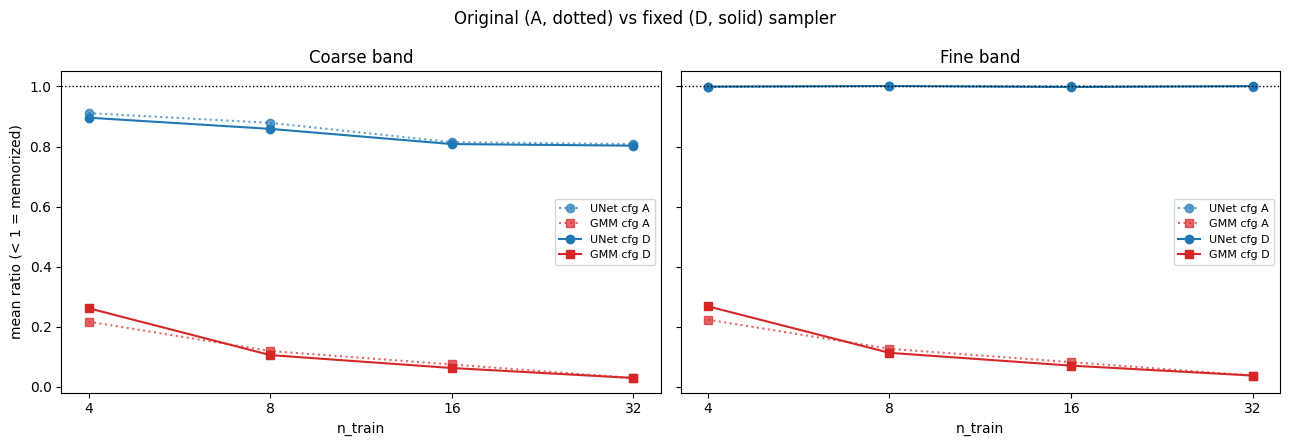

In [10]:
# ── Coarse/fine scores vs n_train: original vs fixed sampler ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, band_key, title in zip(axes, ['coarse_score', 'fine_score'],
                               ['Coarse band', 'Fine band']):
    for cname, ls, alpha in [('A', ':', 0.7), ('D', '-', 1.0)]:
        u = [sweep_results[n]['unet'][cname][band_key].mean().item() for n in N_TRAIN_SWEEP]
        g = [sweep_results[n]['gmm'][cname][band_key].mean().item() for n in N_TRAIN_SWEEP]
        ax.plot(N_TRAIN_SWEEP, u, 'o' + ls, color='tab:blue', alpha=alpha, label=f'UNet cfg {cname}')
        ax.plot(N_TRAIN_SWEEP, g, 's' + ls, color='tab:red',  alpha=alpha, label=f'GMM cfg {cname}')
    ax.axhline(1.0, ls=':', color='black', lw=1)
    ax.set_xscale('log', base=2)
    ax.set_xticks(N_TRAIN_SWEEP)
    ax.set_xticklabels(N_TRAIN_SWEEP)
    ax.set_xlabel('n_train')
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel('mean ratio (< 1 = memorized)')
fig.suptitle('Original (A, dotted) vs fixed (D, solid) sampler', fontsize=12)
plt.tight_layout()
plt.show()

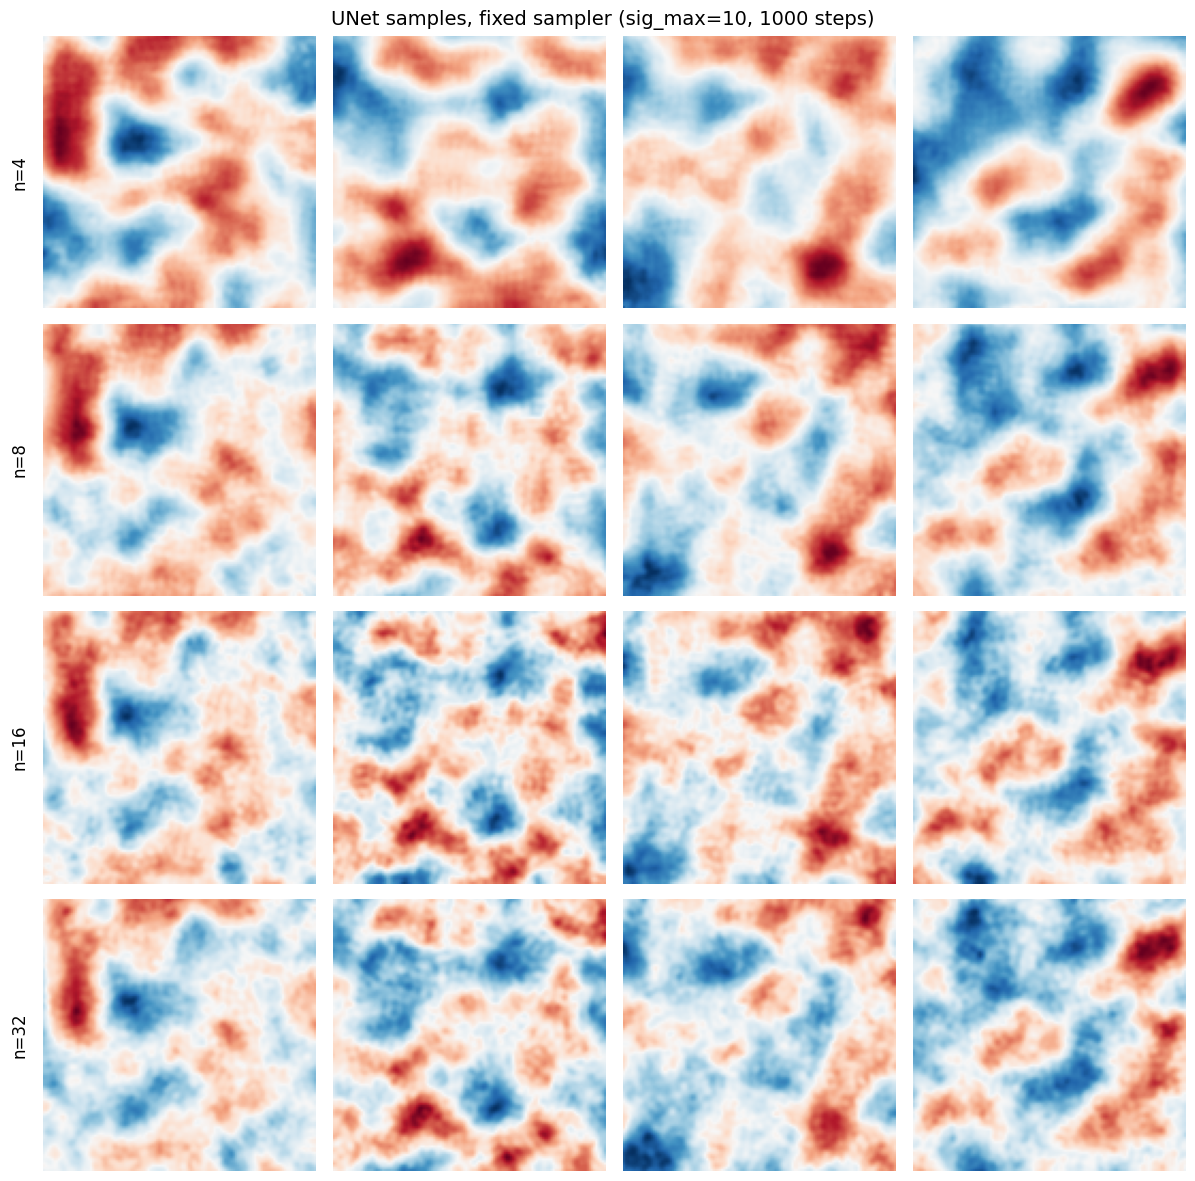

In [11]:
# ── Generated samples under the fixed sampler (config D) ──
n_show = 4
fig, axes = plt.subplots(len(N_TRAIN_SWEEP), n_show, figsize=(3*n_show, 3*len(N_TRAIN_SWEEP)))
for r, n_train in enumerate(N_TRAIN_SWEEP):
    s = sweep_results[n_train]['unet']['D']['samples']
    for col in range(n_show):
        axes[r, col].imshow(s[col].numpy(), cmap='RdBu')
        axes[r, col].axis('off')
    axes[r, 0].text(-0.12, 0.5, f'n={n_train}', transform=axes[r, 0].transAxes,
                    rotation=90, va='center', fontsize=12)
plt.suptitle('UNet samples, fixed sampler (sig_max=10, 1000 steps)', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# ── Summary table and save ──
print('UNet coarse-band mean ratio per config (GMM ceiling in parentheses):')
header = f'{"n_train":>8s} | ' + ' | '.join(f'{c:>17s}' for c in CONFIGS)
print(header)
print('-' * len(header))
for n_train in N_TRAIN_SWEEP:
    row = f'{n_train:>8d} | '
    cols = []
    for cname in CONFIGS:
        if cname in sweep_results[n_train]['unet']:
            u = sweep_results[n_train]['unet'][cname]['coarse_score'].mean().item()
            g = sweep_results[n_train]['gmm'][cname]['coarse_score'].mean().item()
            cols.append(f'{u:>7.4f} ({g:.4f})')
        else:
            cols.append(f'{"—":>17s}')
    print(row + ' | '.join(f'{c:>17s}' for c in cols))

save_obj = {
    'n_train_values': N_TRAIN_SWEEP,
    'configs': CONFIGS,
    'sweep_results': sweep_results,
    'k_centers': k_centers.cpu(),
    'bands': bands,
    'n_gen': N_GEN,
    'note': ('Attribution ablation for the null memorization result of edm_unet_train_size_sweep. '
             'Same trained nets (seed 0, 5000 full-batch steps, P_mean=-1.2, P_std=1.2), evaluated '
             'under sigma_max in {80, 10} x SDE steps in {500, 1000/2000}. sigma_max=10 matches the '
             'training sigma range (P(sigma>10)=0.2%). GMM re-evaluated under every config. '
             'Checkpoints in edm_unet_ntrain_checkpoints.pt.'),
}
save_path = os.path.join(results_dir, 'edm_unet_sigma_fix_ablation.pt')
torch.save(save_obj, save_path)
print(f'\nResults saved to {save_path}')

UNet coarse-band mean ratio per config (GMM ceiling in parentheses):
 n_train |                 A |                 B |                 C |                 D
----------------------------------------------------------------------------------------
       4 |   0.9112 (0.2169) |   0.8954 (0.2755) |   0.8773 (0.2442) |   0.8959 (0.2618)
       8 |   0.8787 (0.1192) |                 — |                 — |   0.8587 (0.1055)
      16 |   0.8144 (0.0743) |                 — |                 — |   0.8081 (0.0626)
      32 |   0.8081 (0.0294) |   0.8322 (0.0294) |   0.8111 (0.0235) |   0.8028 (0.0294)

Results saved to /Users/ishittaiyer/Desktop/Research/results/data/edm_unet_sigma_fix_ablation.pt


## Reading the result

- **C ≈ D ≪ A ≈ B** → the σ-range mismatch is confirmed as the cause: the network was fine,
  the sampler was asking it questions outside its training distribution during the phase
  where the mode decision is made. Adopt σ_max = 10 for all subsequent UNet experiments
  (including re-running the Tikhonov sweeps), and revisit the n_train trend under config D.
- **B ≪ A, C ≈ A** → discretization dominates: use ≥ 1000 steps (or implement the
  deterministic Heun sampler with `edm_sigma_schedule` from `src/edm.py`).
- **All ≈ A** → neither sampler fix explains it; the remaining hypotheses are architectural
  (a small translation-equivariant conv net may fit a Wiener-like average denoiser rather
  than keying on individual samples) or the training σ distribution itself — next step would
  be broader P_mean/P_std or a capacity/receptive-field increase.
- Sanity anchors: config A must reproduce the previous notebook's numbers (coarse 0.81–0.91);
  the GMM ceiling should stay strong under every config (if the GMM degrades under D,
  something is wrong with the σ_max=10 setup itself).